# Aula 6 — PCA: Análise de Componentes Principais
### Centragem, SVD dos dados centrados, variância explicada e matriz de covariância

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 6. A PCA encontra novas direções ortogonais — as
**componentes principais** — ao longo das quais a variação dos dados é mais organizada.
Algebricamente, **PCA é a SVD dos dados centrados**. Vamos centralizar dados sintéticos, montar a
matriz de covariância, obter as componentes pela SVD, medir a **variância explicada**, projetar e
reconstruir, e discutir centragem e escalonamento.

Convenção (como nas notas): $X\in\mathbb{R}^{N\times d}$, linhas = observações, colunas =
variáveis. (Em POD, Aula 7, usaremos a transposta: snapshots em colunas.)

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | SVD, autovalores, covariância |
| `matplotlib` | 3.5 | nuvens 2D/3D, variância explicada |
| `scikit-learn` | 1.0 | `PCA` para comparação |

```bash
pip install numpy matplotlib scikit-learn
```

> A PCA principal é feita **via numpy/SVD**; `scikit-learn` é usado apenas na célula de comparação
> e assume-se instalado.

In [1]:
# --- Imports concentrados ---
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # habilita os gráficos 3D do matplotlib
from sklearn.decomposition import PCA as SklearnPCA
np.random.seed(42)   # fixa o gerador aleatório: os dados sintéticos saem iguais a cada execução


def pca_svd(X):
    '''PCA via SVD dos dados centrados.

    Fazemos a PCA "na mão" em dois passos (centrar + SVD) porque ver esses dois
    passos separados é justamente o ponto pedagógico da aula.

    Retorna: media, componentes V (nas colunas), variancias lambda_i,
    scores Z = B V = U Sigma, e os valores singulares s.
    '''
    # X.mean(axis=0) tira a média ao longo das LINHAS (axis=0), ou seja, a média
    # de cada COLUNA (de cada variável). Resulta num vetor com d médias.
    media = X.mean(axis=0)
    B = X - media                          # centragem: subtrai a média de cada coluna (broadcasting)

    # SVD da matriz centrada B = U Sigma V^T. full_matrices=False devolve a versão
    # "econômica" (U e V só com as colunas/linhas que importam). Vt já é V transposta.
    U, s, Vt = np.linalg.svd(B, full_matrices=False)

    N = X.shape[0]
    lambdas = s**2 / (N - 1)               # variâncias principais: lambda_i = sigma_i^2 / (N-1)
    V = Vt.T                               # componentes principais nas COLUNAS (svd devolve V transposta)

    # Scores Z = U Sigma. Como Sigma é diagonal, "U Sigma" é só multiplicar cada
    # COLUNA k de U pelo valor singular s[k]. O broadcasting "U * s" faz exatamente
    # isso (s tem um valor por coluna), sem precisar montar a matriz diagonal.
    Z = U * s
    return media, V, lambdas, Z, s


print("Ambiente pronto.")


Ambiente pronto.


## Objetivos computacionais

1. Centralizar dados e montar $C=\frac{1}{N-1}B^TB$.
2. Obter PCA por **SVD** e confirmar $\lambda_i=\sigma_i^2/(N-1)$ e $C=V\Lambda V^T$.
3. Visualizar componentes como eixos de **maior variância**; calcular **scores** $Z=BV=U\Sigma$.
4. Medir **variância explicada** $\eta_i,E_k$; **reduzir** e **reconstruir** ($X_k$).
5. Discutir **centragem** e **escalonamento** (covariância vs correlação).

## 1. Dados 2D e centragem

Geramos uma nuvem **correlacionada** e a centralizamos ($B=X-\mathbf{1}\bar{\mathbf{x}}^T$). Após
centrar, a média de cada coluna é ~0.

média dos dados: [4.903 1.914]
média após centrar: [0. 0.]


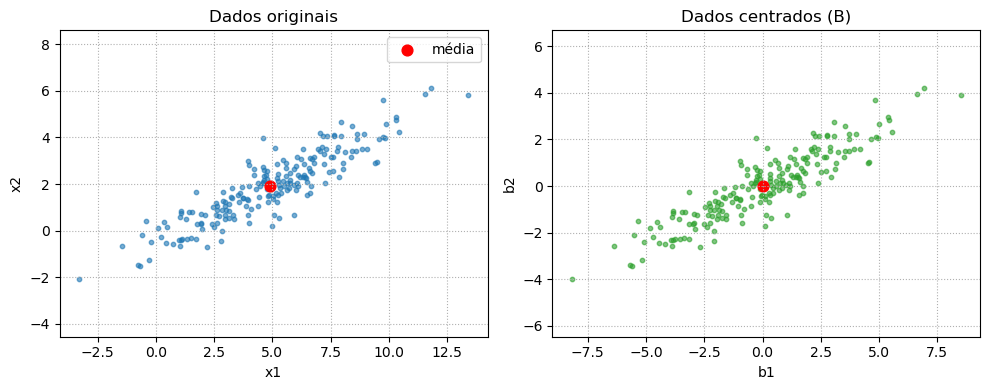

In [2]:
# Nuvem 2D correlacionada: uma direção dominante (1, 0.5) somada a um ruído pequeno.
N = 200
t = np.random.randn(N)                    # N números aleatórios (distribuição normal padrão)

# np.column_stack empilha vetores como COLUNAS de uma matriz. Aqui montamos X (N x 2):
# a coluna 0 é 3*t e a coluna 1 é 1.5*t -> os dois eixos crescem juntos (correlação).
# Somamos 0.6*ruído(N, 2) para a nuvem não ficar numa reta perfeita.
X = np.column_stack([3.0*t, 1.5*t]) + 0.6*np.random.randn(N, 2)
X[:, 0] += 5.0          # desloca toda a coluna 0 em +5 (afasta a nuvem da origem)
X[:, 1] += 2.0          # desloca toda a coluna 1 em +2

# Média de cada coluna (centro da nuvem) e dados centrados B = X - média.
media = X.mean(axis=0)                     # axis=0 -> média por coluna; vetor (2,)
B = X - media                              # subtrai a média de cada coluna (broadcasting)
print("média dos dados:", np.round(media, 3))
print("média após centrar:", np.round(B.mean(axis=0), 12))   # deve ser ~0 em cada coluna

# Dois painéis lado a lado: dados originais (esquerda) e centrados (direita).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Painel da esquerda: a nuvem original e o seu centro (a média).
ax1.scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)           # X[:,0] e X[:,1]: as duas colunas
ax1.scatter(media[0], media[1], color="red", s=60, label="média")   # marca o centro da nuvem
ax1.set_title("Dados originais")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2")
ax1.legend(); ax1.axis("equal"); ax1.grid(True, ls=":")   # axis("equal"): mesma escala em x e y

# Painel da direita: a mesma nuvem depois de centrada (centro agora na origem).
ax2.scatter(B[:, 0], B[:, 1], s=10, alpha=0.6, color="tab:green")
ax2.scatter(0, 0, color="red", s=60)                      # a origem é o novo centro
ax2.set_title("Dados centrados (B)")
ax2.set_xlabel("b1"); ax2.set_ylabel("b2")
ax2.axis("equal"); ax2.grid(True, ls=":")

plt.tight_layout(); plt.show()


## 2. Matriz de covariância

$C=\frac{1}{N-1}B^TB$ é simétrica e semidefinida positiva. Conferimos com `np.cov`.

In [3]:
# Matriz de covariância: montada pela fórmula C = (1/(N-1)) B^T B e conferida com np.cov.
C = (B.T @ B) / (N - 1)        # B.T @ B é a multiplicação matriz-matriz (operador @)
print("C =\n", np.round(C, 4))
print("simétrica?", np.allclose(C, C.T))                 # C deve ser igual à sua transposta

# np.cov espera, por padrão, variáveis nas LINHAS; com rowvar=False dizemos que cada
# COLUNA é uma variável (a convenção desta aula). Deve dar a mesma matriz C.
print("coincide com np.cov?", np.allclose(C, np.cov(X, rowvar=False)))

# eigvalsh: autovalores de uma matriz simétrica ("h" de Hermitiana). Para C devem ser >= 0.
print("autovalores de C (>=0):", np.round(np.linalg.eigvalsh(C), 4))


C =
 [[7.8248 3.8035]
 [3.8035 2.2661]]
simétrica? True
coincide com np.cov? True
autovalores de C (>=0): [0.3346 9.7562]


## 3. PCA via SVD: $\lambda_i=\sigma_i^2/(N-1)$

As componentes principais são as colunas de $V$ (da SVD de $B$); as variâncias são
$\lambda_i=\sigma_i^2/(N-1)$ e devem coincidir com os autovalores de $C$.

In [4]:
# PCA por SVD e checagem contra a decomposição espectral de C.
media, V, lambdas, Z, s = pca_svd(X)      # desempacota os 5 retornos da função

# eigvalsh devolve os autovalores em ordem CRESCENTE. np.sort(...)[::-1] inverte a
# ordem (o "[::-1]" lê o array de trás para frente), deixando do maior para o menor,
# que é a ordem das variâncias principais lambda_i.
autovals_C = np.sort(np.linalg.eigvalsh(C))[::-1]
print("lambda_i (= sigma_i^2/(N-1)):", np.round(lambdas, 4))
print("autovalores de C            :", np.round(autovals_C, 4))
print("coincidem?", np.allclose(lambdas, autovals_C))

# np.diag(lambdas) monta a matriz diagonal Lambda com os lambda_i na diagonal.
# Conferimos a identidade C = V Lambda V^T (decomposição espectral de C).
print("C == V Lambda V^T ?", np.allclose(C, V @ np.diag(lambdas) @ V.T))


lambda_i (= sigma_i^2/(N-1)): [9.7562 0.3346]
autovalores de C            : [9.7562 0.3346]
coincidem? True
C == V Lambda V^T ? True


## 4. Componentes principais = eixos de maior variância

Desenhamos $\mathbf{v}_i$ escalados por $\sqrt{\lambda_i}$ (1 desvio padrão) sobre a nuvem.

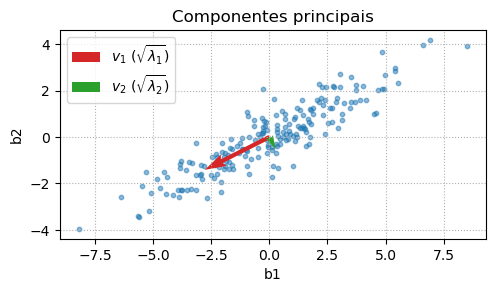

In [5]:
# Desenhamos as duas componentes principais como setas sobre os dados centrados.
# Cada seta v_i tem o COMPRIMENTO escalado por sqrt(lambda_i) = 1 desvio padrão
# naquela direção, então a seta mais longa é a direção de maior variância.
vec1 = V[:, 0] * np.sqrt(lambdas[0])      # 1a componente (coluna 0 de V) x sqrt(lambda_1)
vec2 = V[:, 1] * np.sqrt(lambdas[1])      # 2a componente (coluna 1 de V) x sqrt(lambda_2)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(B[:, 0], B[:, 1], s=10, alpha=0.5)            # nuvem centrada ao fundo

# plt.quiver(x0, y0, dx, dy) desenha uma seta de (x0,y0) na direção (dx,dy). As opções
# angles/scale_units/scale=1 garantem que a seta tenha o comprimento REAL do vetor.
# Desenhamos as duas setas em chamadas separadas (mais claro que um laço para 2 vetores):
ax.quiver(0, 0, vec1[0], vec1[1], angles="xy", scale_units="xy", scale=1,
          color="tab:red", width=0.01, label=r"$v_1$ ($\sqrt{\lambda_1}$)")
ax.quiver(0, 0, vec2[0], vec2[1], angles="xy", scale_units="xy", scale=1,
          color="tab:green", width=0.01, label=r"$v_2$ ($\sqrt{\lambda_2}$)")

ax.set_aspect("equal"); ax.grid(True, ls=":"); ax.legend()
ax.set_title("Componentes principais"); ax.set_xlabel("b1"); ax.set_ylabel("b2")
plt.show()


## 5. Scores: dados nas coordenadas principais

$Z=BV=U\Sigma$. Nas coordenadas principais os dados ficam **descorrelacionados** (eixos alinhados
à variância).

Z = BV == U Sigma ? True
covariância dos scores (quase diagonal):
 [[ 9.7562 -0.    ]
 [-0.      0.3346]]


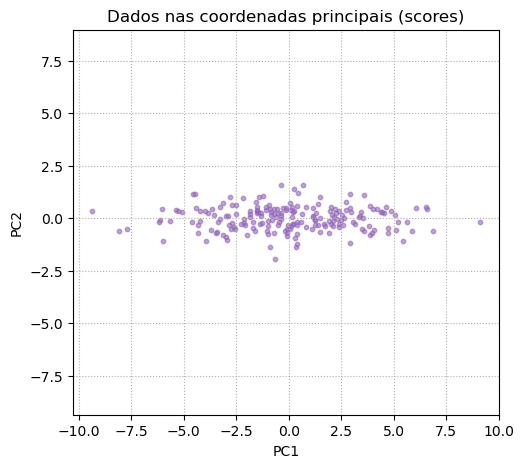

In [6]:
# Scores: as coordenadas dos dados nas direções principais. Confirmamos Z = B V = U Sigma.
print("Z = BV == U Sigma ?", np.allclose(B @ V, Z))      # B @ V projeta a nuvem nas componentes

# Nas coordenadas principais os eixos ficam DESCORRELACIONADOS: a covariância dos scores
# é (quase) diagonal. rowvar=False de novo trata cada coluna de Z como uma variável.
print("covariância dos scores (quase diagonal):\n", np.round(np.cov(Z, rowvar=False), 4))

# Gráfico dos dados já reescritos nas coordenadas principais (PC1 no eixo x, PC2 no y).
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.6, color="tab:purple")   # coluna 0 = PC1, coluna 1 = PC2
ax.set_title("Dados nas coordenadas principais (scores)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.axis("equal"); ax.grid(True, ls=":")
plt.show()


## 6. Variância explicada

$\eta_i=\dfrac{\lambda_i}{\sum_j\lambda_j}$ e $E_k=\sum_{i\le k}\eta_i$.

PC1: eta = 0.967 | E_1 = 0.967
PC2: eta = 0.033 | E_2 = 1.000


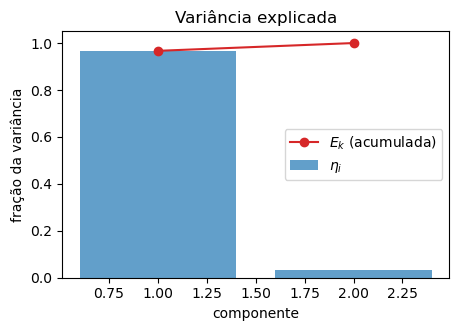

In [7]:
# Variância explicada: fração por componente (eta) e fração acumulada (E_k).
eta = lambdas / lambdas.sum()             # cada lambda_i dividido pela soma de todos -> fração
Ek = np.cumsum(eta)                        # soma acumulada: Ek[0]=eta[0], Ek[1]=eta[0]+eta[1], ...

# range(len(eta)) gera 0, 1, ...; somamos 1 só para imprimir "PC1", "PC2" (1-based).
for i in range(len(eta)):
    print(f"PC{i+1}: eta = {eta[i]:.3f} | E_{i+1} = {Ek[i]:.3f}")

# Gráfico: barras = fração individual eta_i; linha = fração acumulada E_k.
componentes = range(1, len(eta) + 1)      # rótulos do eixo x: 1, 2, ... (número da componente)
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(componentes, eta, alpha=0.7, label=r"$\eta_i$")
ax.plot(componentes, Ek, "o-", color="tab:red", label=r"$E_k$ (acumulada)")
ax.set_xlabel("componente"); ax.set_ylabel("fração da variância")
ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Variância explicada")
plt.show()


## 7. Exemplo 2D trabalhado das notas (Seção 9)

Para a matriz centrada $B$ das notas, espera-se $\lambda_1=2$, $\lambda_2=\tfrac12$,
$\eta_1=0.8$, $\sigma_1=2\sqrt2$, $\sigma_2=\sqrt2$ e scores $Z$ conhecidos.

In [8]:
# Matriz B exata das notas (N=5 observações em R^2), já centrada.
r2 = np.sqrt(2)                           # atalho para sqrt(2); 1/r2 é 1/sqrt(2)
Bex = np.array([[ r2,    r2],
                [-r2,   -r2],
                [ 1/r2, -1/r2],
                [-1/r2,  1/r2],
                [ 0.0,   0.0]])

# Covariância da mão: C = (1/(N-1)) B^T B. Bex.shape[0] é o número de linhas (N=5).
Cex = (Bex.T @ Bex) / (Bex.shape[0] - 1)
print("C =\n", np.round(Cex, 4), "(esperado [[1.25,0.75],[0.75,1.25]])")

# Autovalores de Cex (simétrica), do maior para o menor com np.sort(...)[::-1].
vals = np.sort(np.linalg.eigvalsh(Cex))[::-1]
print("lambda:", np.round(vals, 4), "(esperado 2 e 0.5) | eta_1 =", round(vals[0]/vals.sum(), 3))

# SVD dos dados centrados: os valores singulares s satisfazem s_i^2 = (N-1) lambda_i.
U, s, Vt = np.linalg.svd(Bex, full_matrices=False)
print("sigma:", np.round(s, 4), "(esperado 2*sqrt(2) =", round(2*r2, 4), ", sqrt(2) =", round(r2, 4), ")")

# Scores Z = B V. Como svd devolve Vt (= V transposta), recuperamos V com Vt.T.
print("scores Z = B V =\n", np.round(Bex @ Vt.T, 4))


C =
 [[1.25 0.75]
 [0.75 1.25]] (esperado [[1.25,0.75],[0.75,1.25]])
lambda: [2.  0.5] (esperado 2 e 0.5) | eta_1 = 0.8
sigma: [2.8284 1.4142] (esperado 2*sqrt(2) = 2.8284 , sqrt(2) = 1.4142 )
scores Z = B V =
 [[-2. -0.]
 [ 2.  0.]
 [ 0. -1.]
 [-0.  1.]
 [ 0.  0.]]


## 8. Dados 3D e redução para 2D

Uma nuvem 3D com variância concentrada num **plano**: as duas primeiras componentes capturam
quase toda a variância, e a projeção nos scores PC1–PC2 revela a estrutura.

variâncias principais: [6.885 2.536 0.023]
E_2 (duas primeiras) = 0.9976


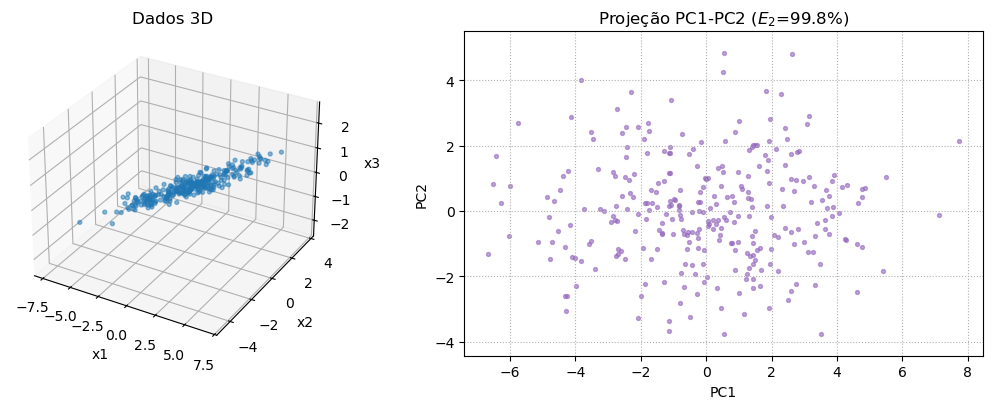

In [9]:
# Nuvem 3D quase planar: as 3 coordenadas são combinações de só DOIS fatores (a e b),
# então a nuvem vive quase num plano. O ruído 0.15*randn dá uma pequena espessura.
N3 = 300
a, b = np.random.randn(N3), np.random.randn(N3)   # dois vetores aleatórios independentes
X3 = np.column_stack([2.5*a + 0.3*b,              # coluna x1
                      1.5*b,                       # coluna x2
                      0.8*a - 0.4*b]) + 0.15*np.random.randn(N3, 3)

media3, V3, lam3, Z3, s3 = pca_svd(X3)            # PCA da nuvem 3D

# E_2 = fração de variância nas DUAS primeiras componentes. lam3[:2] pega os 2 primeiros.
E2 = lam3[:2].sum() / lam3.sum()
print("variâncias principais:", np.round(lam3, 3))
print("E_2 (duas primeiras) =", round(E2, 4))

# Painel 1: nuvem em 3D. Painel 2: a projeção nos scores PC1-PC2 (vista "de frente" do plano).
fig = plt.figure(figsize=(11, 4.2))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")  # subplot 3D
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=8, alpha=0.5)   # as 3 colunas viram x, y, z
ax1.set_title("Dados 3D")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("x3")

ax2 = fig.add_subplot(1, 2, 2)                    # subplot 2D comum
ax2.scatter(Z3[:, 0], Z3[:, 1], s=8, alpha=0.6, color="tab:purple")   # PC1 x PC2
ax2.set_title(f"Projeção PC1-PC2 ($E_2$={E2:.1%})")   # {E2:.1%} formata como porcentagem
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.axis("equal"); ax2.grid(True, ls=":")

plt.tight_layout(); plt.show()


## 9. Redução e reconstrução

$X_k=\mathbf{1}\bar{\mathbf{x}}^T+U_k\Sigma_kV_k^T$; o erro relativo na parte centrada é $1-E_k$.

In [10]:
# Reconstrução dos dados 3D usando só k componentes; o erro relativo^2 deve dar 1 - E_k.
B3 = X3 - media3                           # dados centrados (a média é recolocada só no fim)
normB = np.linalg.norm(B3, 'fro')          # norma de Frobenius: "tamanho" total da matriz B3

for k in [1, 2, 3]:
    # Z3[:, :k] pega as k primeiras COLUNAS dos scores; V3[:, :k] as k primeiras componentes.
    # O produto reconstrói a parte centrada com k componentes: B_k = U_k Sigma_k V_k^T.
    Bk = Z3[:, :k] @ V3[:, :k].T
    # Erro relativo ao quadrado = ||B3 - Bk||_F^2 / ||B3||_F^2.
    erro = np.linalg.norm(B3 - Bk, 'fro')**2 / normB**2
    E_k = lam3[:k].sum() / lam3.sum()      # variância explicada pelas k primeiras
    print(f"k={k}: erro relativo^2 = {erro:.4f} | 1 - E_k = {1-E_k:.4f}")


k=1: erro relativo^2 = 0.2709 | 1 - E_k = 0.2709
k=2: erro relativo^2 = 0.0024 | 1 - E_k = 0.0024
k=3: erro relativo^2 = 0.0000 | 1 - E_k = 0.0000


## 10. O que acontece se **não** centralizar

Sem centrar, a primeira "direção" da SVD é puxada para a **posição média** da nuvem, não para a
direção de maior variação (Exercício 5).

1a direção SEM centrar: [-0.922 -0.387] (tende à direção da média [0.932 0.364] )
1a direção COM centrar: [-0.892 -0.453] (direção real de variação)


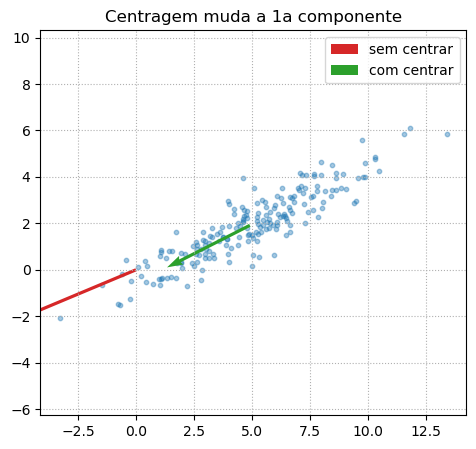

In [11]:
# Comparação: a 1a direção da SVD nos dados SEM centrar vs COM centrar.
U_nc, s_nc, Vt_nc = np.linalg.svd(X, full_matrices=False)   # SVD direto em X (sem centrar)
v1_nc = Vt_nc[0]            # 1a direção sem centrar: 1a LINHA de Vt = 1a componente
v1_c = V[:, 0]             # 1a direção com centrar: 1a COLUNA de V (da PCA já feita)

# Sem centrar, v1 tende a apontar para a posição média da nuvem. media/||media|| é o
# vetor média normalizado (comprimento 1), só para comparar a DIREÇÃO.
print("1a direção SEM centrar:", np.round(v1_nc, 3),
      "(tende à direção da média", np.round(media/np.linalg.norm(media), 3), ")")
print("1a direção COM centrar:", np.round(v1_c, 3), "(direção real de variação)")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4)            # nuvem original (não centrada)

# Seta vermelha (sem centrar) parte da ORIGEM; multiplicamos por 8 só para a seta ficar visível.
ax.quiver(0, 0, v1_nc[0]*8, v1_nc[1]*8, angles="xy", scale_units="xy", scale=1,
          color="tab:red", label="sem centrar")
# Seta verde (com centrar) parte do CENTRO da nuvem. "*media" desempacota media em (x0, y0).
ax.quiver(*media, v1_c[0]*4, v1_c[1]*4, angles="xy", scale_units="xy", scale=1,
          color="tab:green", label="com centrar")

ax.set_title("Centragem muda a 1a componente")
ax.legend(); ax.grid(True, ls=":"); ax.axis("equal")
plt.show()


## 11. Escalonamento: covariância vs correlação

Quando as variáveis têm **escalas muito diferentes**, a de maior escala domina a PCA. Padronizar
(÷ desvio padrão) equivale a usar a matriz de **correlação** e reequilibra as componentes
(Exercício 6).

variância explicada (covariância): [1. 0.]
variância explicada (correlação) : [0.947 0.053]


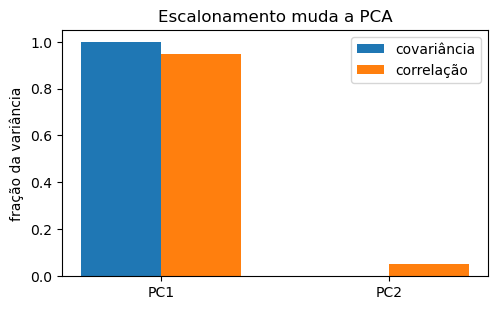

In [12]:
# Duas variáveis com escalas muito diferentes: x1 ~ O(1000) e x2 ~ O(1).
N2 = 300
z = np.random.randn(N2)
Xs = np.column_stack([1000.0*z + 50*np.random.randn(N2),   # variável de escala grande
                      1.0*z + 0.5*np.random.randn(N2)])     # variável de escala pequena

# PCA na COVARIÂNCIA (sem padronizar). Só queremos as variâncias lam_cov, então
# usamos "_" para descartar os outros retornos de pca_svd (media, V, Z, s).
_, _, lam_cov, _, _ = pca_svd(Xs)

# PCA na CORRELAÇÃO: padronizamos cada coluna (subtrai média, divide pelo desvio padrão).
# Xs.std(0, ddof=1) é o desvio padrão por coluna (axis=0) com a mesma normalização (N-1) da covariância.
Xstd = (Xs - Xs.mean(0)) / Xs.std(0, ddof=1)
_, _, lam_cor, _, _ = pca_svd(Xstd)

print("variância explicada (covariância):", np.round(lam_cov/lam_cov.sum(), 3))
print("variância explicada (correlação) :", np.round(lam_cor/lam_cor.sum(), 3))

# Barras lado a lado: deslocamos um grupo para -w/2 e o outro para +w/2 para não se sobreporem.
fig, ax = plt.subplots(figsize=(5.5, 3.2))
w = 0.35                                   # largura de cada barra
posicoes = np.arange(2)                    # posições base no eixo x: [0, 1] (PC1, PC2)
ax.bar(posicoes - w/2, lam_cov/lam_cov.sum(), w, label="covariância")
ax.bar(posicoes + w/2, lam_cor/lam_cor.sum(), w, label="correlação")
ax.set_xticks([0, 1]); ax.set_xticklabels(["PC1", "PC2"])
ax.set_ylabel("fração da variância")
ax.set_title("Escalonamento muda a PCA"); ax.legend()
plt.show()


## 12. (Opcional) Comparação com `scikit-learn`

Se `scikit-learn` estiver instalado, comparamos as variâncias explicadas (as componentes podem
diferir apenas no **sinal**).

In [13]:
# Comparação com o scikit-learn: ele faz a mesma PCA (centra por dentro e usa SVD).
# .fit(X) calcula a PCA; .explained_variance_ são as variâncias lambda_i (já ordenadas).
p = SklearnPCA().fit(X)
print("sklearn explained_variance_:", np.round(p.explained_variance_, 4))
print("numpy  lambdas             :", np.round(lambdas, 4))

# Comparamos os dois conjuntos de variâncias (ordenados do maior para o menor em ambos).
# As COMPONENTES podem diferir só no sinal, mas as VARIÂNCIAS devem coincidir.
print("coincidem?", np.allclose(np.sort(p.explained_variance_)[::-1], np.sort(lambdas)[::-1]))


sklearn explained_variance_: [9.7562 0.3346]
numpy  lambdas             : [9.7562 0.3346]
coincidem? True


## Síntese da aula

- **PCA = SVD dos dados centrados.** Centralize ($B=X-\mathbf{1}\bar{\mathbf{x}}^T$), monte
  $C=\frac{1}{N-1}B^TB$; as componentes são as colunas de $V$ e as variâncias $\lambda_i=\sigma_i^2/(N-1)$.
- Os **scores** $Z=BV=U\Sigma$ reescrevem os dados em coordenadas descorrelacionadas; a
  **variância explicada** $E_k$ guia a redução de dimensão, com erro de reconstrução $1-E_k$.
- **Centragem** e **escalonamento** mudam o resultado e são decisões de modelagem.

## Limitações a discutir

- PCA é **linear**: variedades curvas exigem muitas componentes.
- Sensível à **escala** (padronização) e a **outliers**.
- **Variância ≠ importância** física: um modo de baixa energia pode reger instabilidade/transição.
- **Desalinhamento** (translação/rotação de estruturas) infla o número de componentes — relevante
  para escoamentos.

## Experimentos sugeridos

1. Refaça os Exercícios 2 ($C=\operatorname{diag}(4,1)$), 3 ($\begin{bmatrix}2&1\\1&2\end{bmatrix}$)
   e 4 ($\sigma=(20,10,5,2,1)$).
2. Pontos colineares $(1,2),(2,4),(3,6)$ → posto de $B$ = 1 (Exercício 1).
3. Acrescente um **outlier** e veja as componentes mudarem.
4. Compare PCA com/sem padronização em variáveis de escalas diferentes.

*Próxima aula (Aula 7): **POD** — a mesma SVD aplicada a **snapshots** de escoamento, com modos
espaciais e coeficientes temporais e o conceito de energia modal.*